# STEP 0: Set up

To get started on this notebook, you’ll need to restore any variables
from previous notebooks to your workspace. To save time and memory, make
sure to specify which variables you want to load.

In [13]:
%store -r

Unable to restore variable 'ndvi_diff', ignoring (use %store -d to forget!)
The error was: <class 'KeyError'>


You will also need to import any libraries you are using in this
notebook, since they won’t carry over from the previous notebook:

In [14]:
# Import libraries
import xarray as xr
import rioxarray as rxr

import matplotlib.pyplot as plt
import hvplot.xarray
import hvplot.pandas

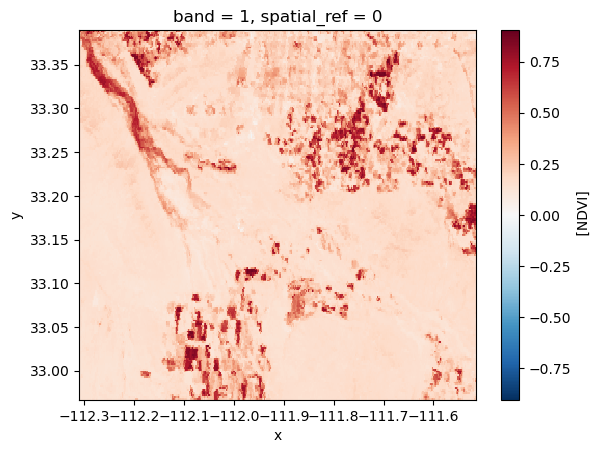

In [15]:
# simple plot - first tif image 
rxr.open_rasterio(ndvi_paths[0], mask_and_scale = True).squeeze().plot()

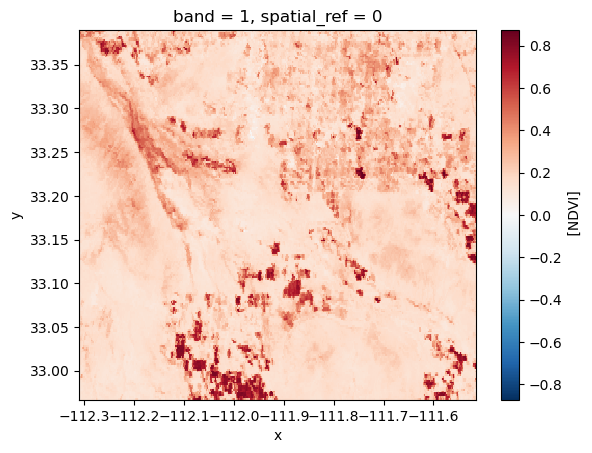

In [16]:
# simple plot - last tif image 
rxr.open_rasterio(ndvi_paths[-1], mask_and_scale=True).squeeze().plot()

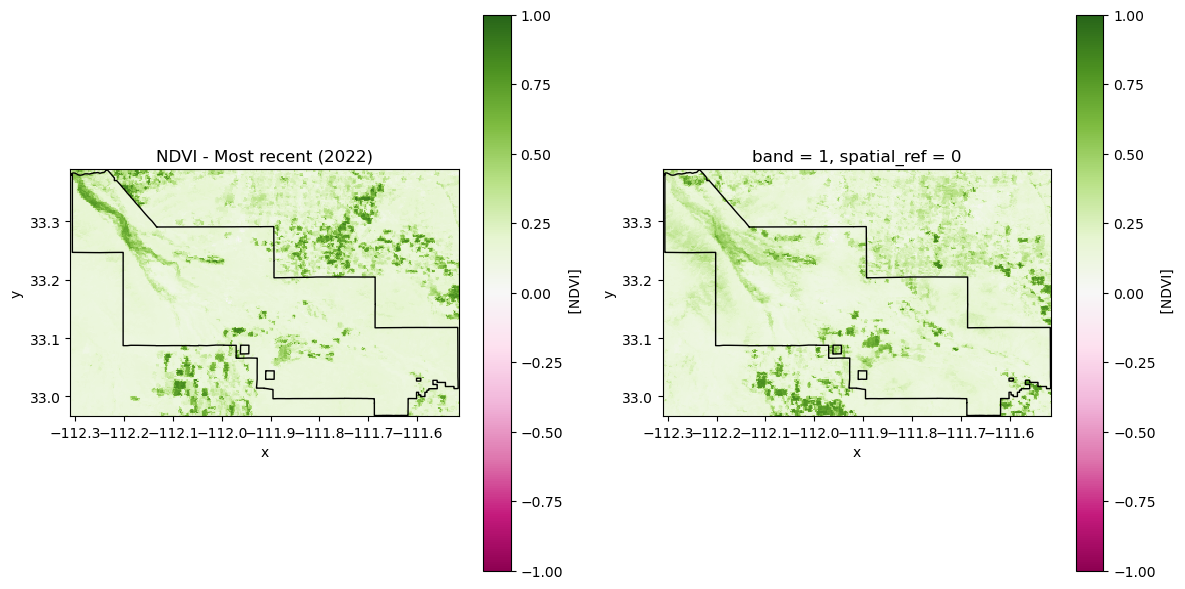

In [17]:
# plot them side by side
ndvi_first = rxr.open_rasterio(ndvi_paths[0], mask_and_scale = True).squeeze()
ndvi_last = rxr.open_rasterio(ndvi_paths[-1], mask_and_scale = True).squeeze()

### make side by side subplots
### 1 subplot with 1 row + 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

### plot first ndvi with gila river boundary
ndvi_first.plot(ax=axes[0], cmap=plt.cm.PiYG, vmin=-1, vmax=1)
gila_boundary_gdf.plot(ax=axes[0], edgecolor='black', facecolor='none', linewidth=1)
axes[0].set_title("NDVI - Earliest (2001)")

### plot last ndvi with gila river boundary
ndvi_last.plot(ax=axes[1], cmap=plt.cm.PiYG, vmin=-1, vmax=1)
gila_boundary_gdf.plot(ax=axes[1], edgecolor='black', facecolor='none', linewidth=1)
axes[0].set_title("NDVI - Most recent (2022)")

### play with layout
plt.tight_layout()
plt.show()

# STEP 3: Plot NDVI

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It: Plot the change in NDVI spatially</div></div><div class="callout-body-container callout-body"><p>Complete the following:</p>
<ul>
<li>Select data from 2021 to 2023 (3 years after the <span
data-__quarto_custom="true" data-__quarto_custom_type="Shortcode"
data-__quarto_custom_context="Inline"
data-__quarto_custom_id="1"></span>)</li>
<li>Take the temporal mean (over the <strong>date</strong>, not
spatially)</li>
<li>Get the NDVI variable (should be a DataArray, not a Dataset)</li>
<li>Repeat for the data from 2018 to 2020 (3 years before the <span
data-__quarto_custom="true" data-__quarto_custom_type="Shortcode"
data-__quarto_custom_context="Inline"
data-__quarto_custom_id="2"></span>)</li>
<li>Subtract the 2018-2020 time period <strong>from</strong> the
2021-2023 time period</li>
<li>Plot the result using a <strong>diverging</strong> color map like
<code>cmap=plt.cm.PiYG</code></li>
</ul>
<p>There are different types of color maps for different types of data.
In this case, we want decreases to be a different color from increases,
so we should use a <strong>diverging</strong> color map. Check out
available colormaps in the <a
href="https://matplotlib.org/stable/tutorials/colors/colormaps.html">matplotlib
documentation</a>.</p></div></div>

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-extra"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Looking for an Extra Challenge?</div></div><div class="callout-body-container callout-body"><p>For an extra challenge, add the <span data-__quarto_custom="true"
data-__quarto_custom_type="Shortcode"
data-__quarto_custom_context="Inline"
data-__quarto_custom_id="3"></span> boundary to the plot.</p></div></div>

I initially worked with the specified years. However, other time periods 
were mentioned during class last week. I therefore stuck to these, 
which were **2001-2011** and **2012-2022**.

In [18]:
ndvi_data_2001_2011 = ndvi_da.sel(date=slice('2001', '2011')).mean('date').NDVI

ndvi_data_2012_2022 = ndvi_da.sel(date=slice('2012', '2022')).mean('date').NDVI

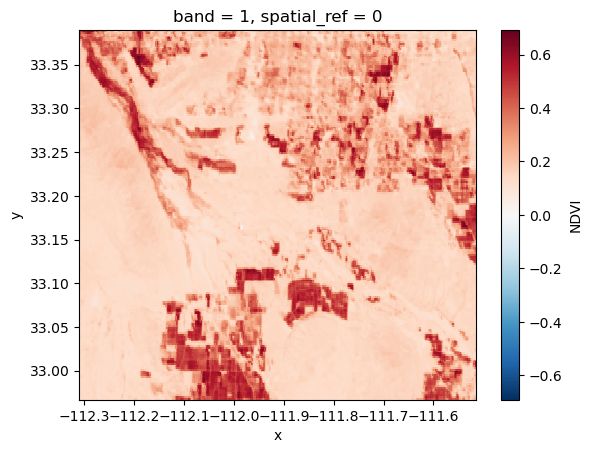

In [19]:
ndvi_data_2001_2011.plot()

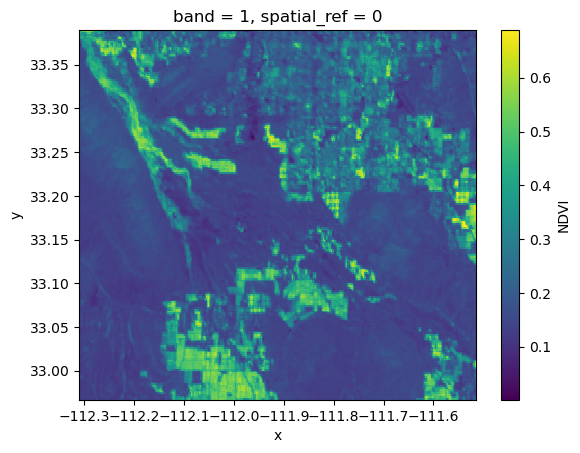

In [20]:
ndvi_data_2012_2022.plot()

In [21]:
# Compute the difference in NDVI before and after
ndvi_diff = (
    ndvi_data_2012_2022 
    - 
    ndvi_data_2001_2011
)


# Plot the difference
(
    ndvi_diff.hvplot(x='x', y='y', cmap='PiYG', geo=True,
                     title = "NDVI changes in Gila River Indian Community\nfrom 2001-2011 to 2012-2022")
    *
    gila_boundary_gdf.hvplot(geo=True, fill_color=None, line_color='black')
)

:Overlay
   .Image.I    :Image   [x,y]   (NDVI)
   .Polygons.I :Polygons   [Longitude,Latitude]

This figure allows us to examine how the health of the vegetation has changed 
over the two time periods. A **positive** value indicates that the health of 
the **vegetation has improved**, while a **negative** value indicates that it 
has **deteriorated**.

# STEP -1: Wrap up

Don’t forget to store your variables so you can use them in other
notebooks! Replace `var1` and `var2` with the variable you want to save,
separated by spaces.

In [22]:
%store ndvi_diff

Stored 'ndvi_diff' (DataArray)


Finally, be sure to `Restart` and `Run all` to make sure your notebook
works all the way through!